In [36]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [66]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [67]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [68]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [70]:
def chi_sq(theta, uncertainty_multiplier = 1):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/(df['E_COIN_RATE'] * uncertainty_multiplier)) / len(df - len(theta))

In [71]:
p0 = [0, 750, 750]
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)

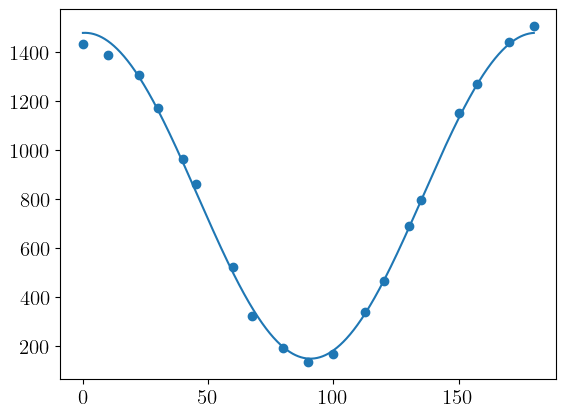

In [ ]:
plt.scatter(df["ANGLE"], df["COIN_RATE"])
x = np.linspace(0, 180, 1000)
plt.plot(x, model(x, *pcurve_fit))
print(chi_sq(pcurve_fit))

In [76]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE'])

In [77]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [78]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

100%|██████████| 25000/25000 [01:40<00:00, 249.69it/s]


State([[ -1.60133579 669.63141142 812.56296313]
 [ -1.53316549 670.3143189  812.06410656]
 [ -1.52552545 669.62871419 811.77849584]
 [ -1.68823614 670.84544972 812.62209481]
 [ -1.62109915 671.40366345 813.43680933]
 [ -1.59305002 669.40554878 812.74853252]
 [ -1.61505493 671.19964951 813.00744337]
 [ -1.62040241 669.96439136 812.42076454]
 [ -1.55366593 671.29496805 812.71611824]
 [ -1.57045224 669.84555395 812.29947278]
 [ -1.51549627 670.24896103 813.07658017]
 [ -1.67660414 670.78869156 813.3712788 ]
 [ -1.50309273 670.22750202 812.69086359]
 [ -1.53185427 668.73737628 811.11013797]
 [ -1.48497581 671.21797484 813.26780634]
 [ -1.59453932 671.23864378 813.3671792 ]], log_prob=[-1132.25653014 -1131.4956366  -1133.27851849 -1132.72210833
 -1132.59136379 -1133.23991438 -1131.3108918  -1131.63220428
 -1130.9499826  -1131.54686211 -1132.06761098 -1133.60115782
 -1131.61818631 -1138.65802888 -1132.59796431 -1131.91708751], blobs=None, random_state=('MT19937', array([ 802883329, 378211230

In [79]:
#names of parameters
param_labels = [
    "Phase",
    "Amplitude",
    "Baseline"
]

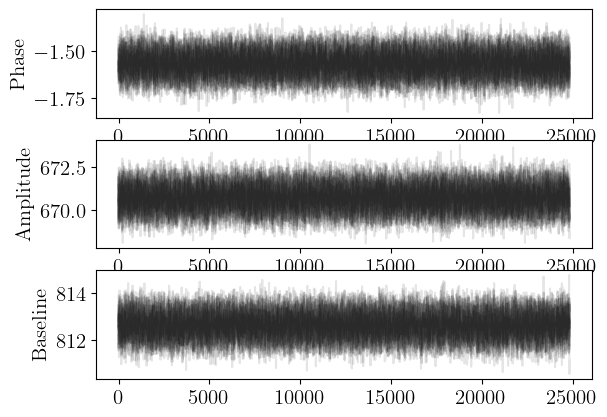

In [80]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

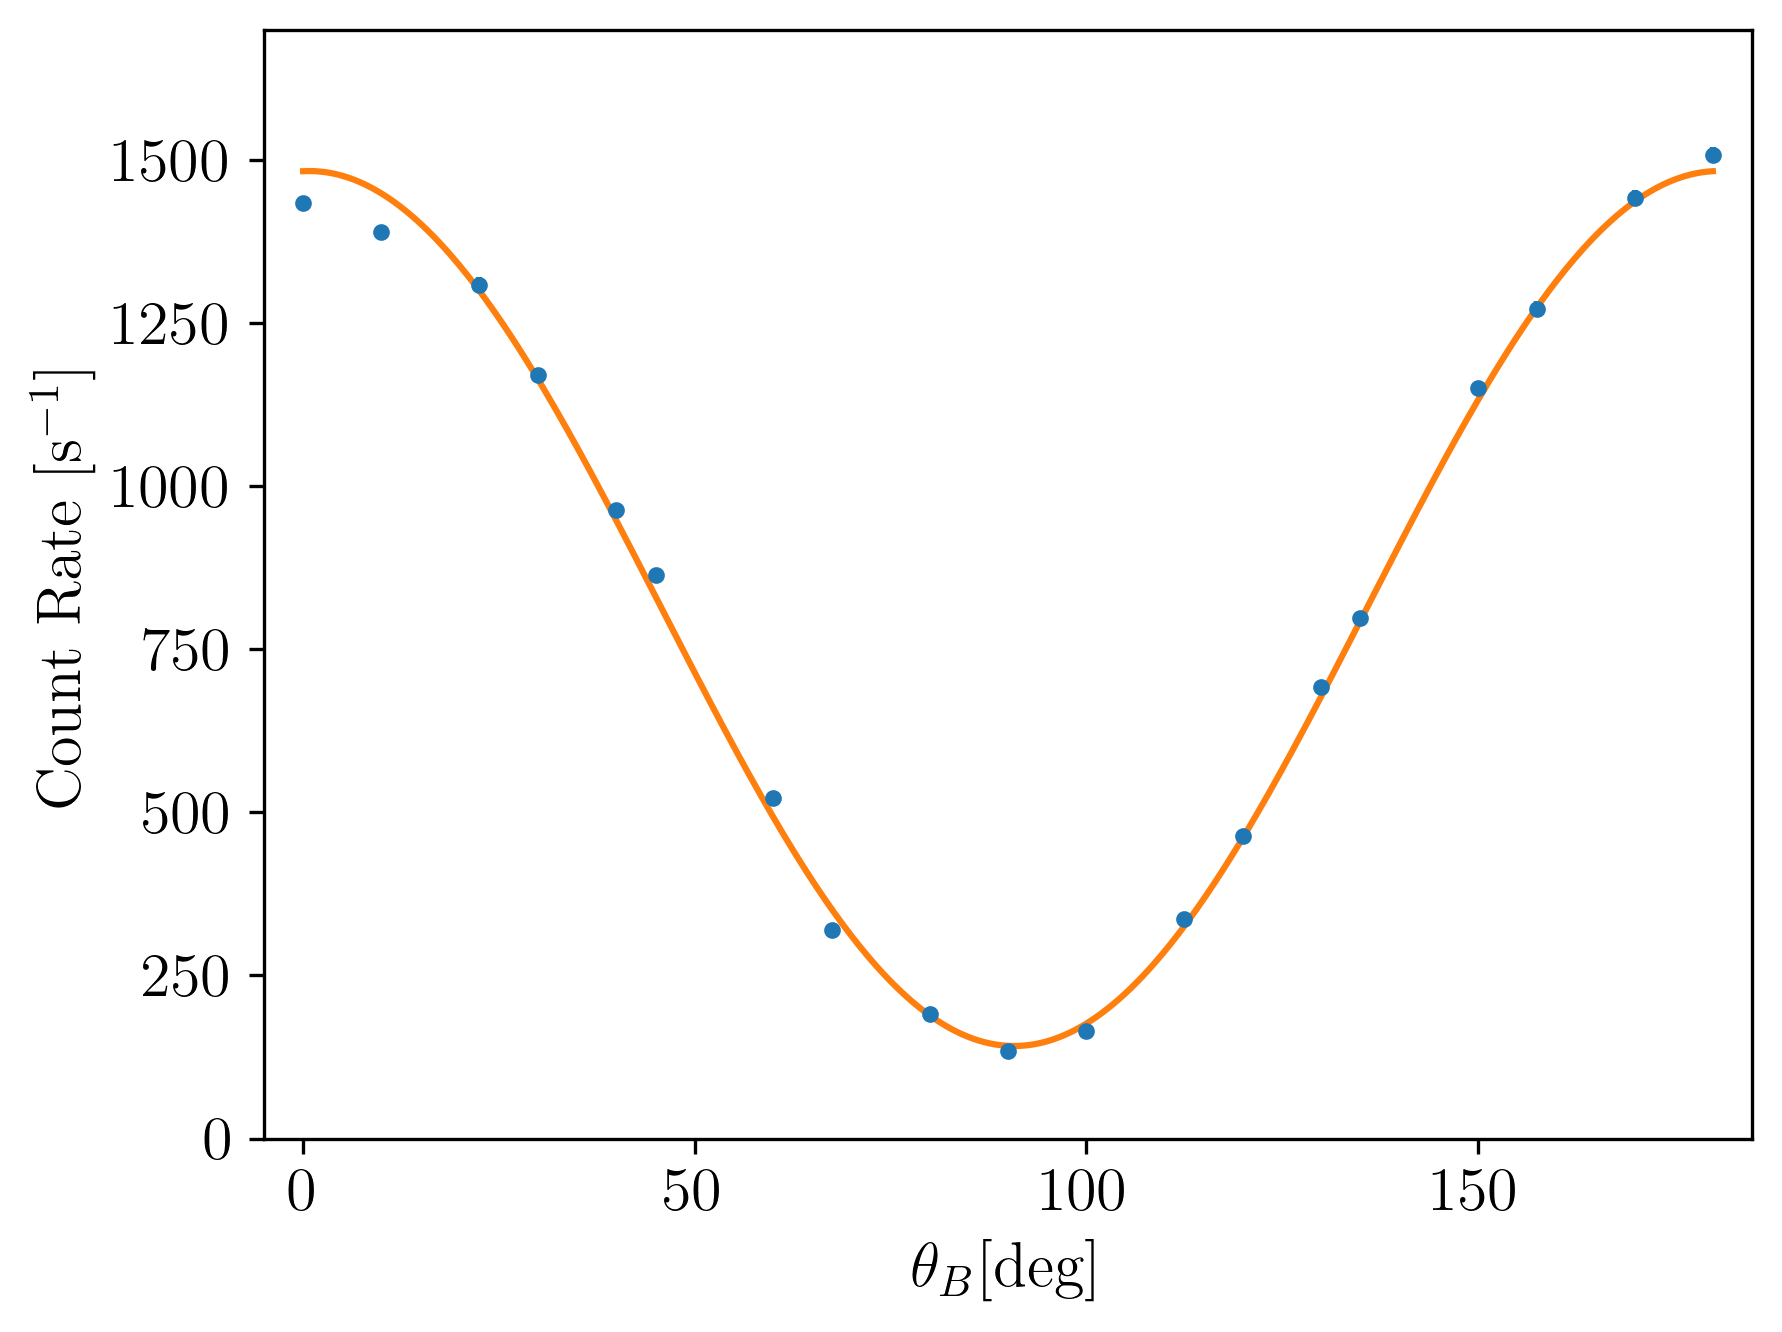

In [109]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"], ls="", marker=".")
x = np.linspace(0, 180, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)

ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit.png")

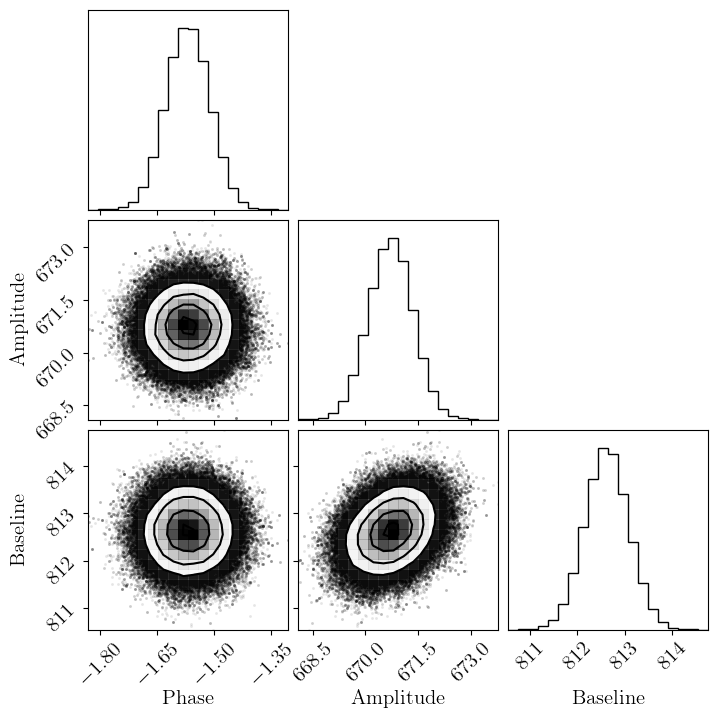

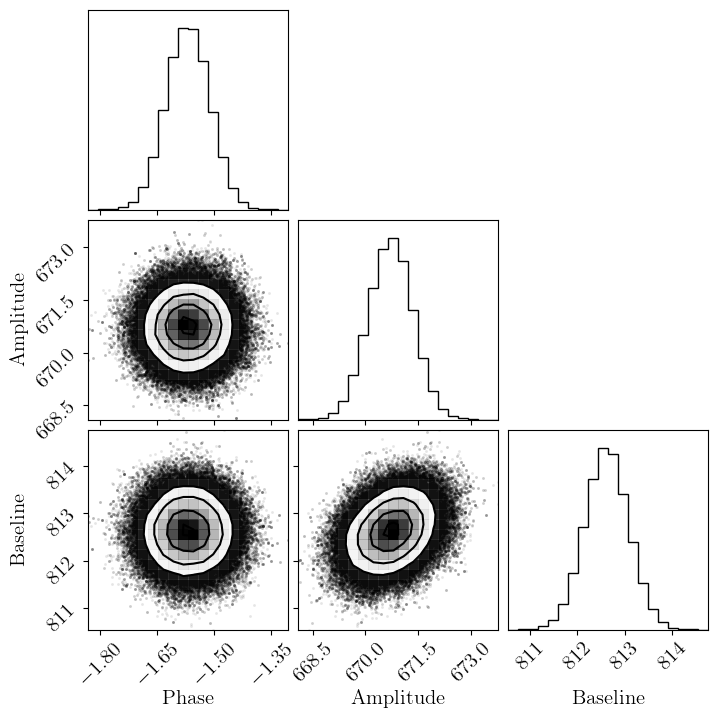

In [86]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels)

In [118]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [119]:

results.to_csv("mcmc_fit.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.569063,0.057029,0.114057,-0.072691
Amplitude,670.734819,0.628888,1.257775,0.001875
Baseline,812.628194,0.464300,0.928600,0.001143


In [94]:
chi_sq_mcmc = chi_sq(np.median(chain, axis = 0))
chi_sq_mcmc
#quite high, will try rescaling errors 

np.float64(59.500718964365205)

7.713670913667839


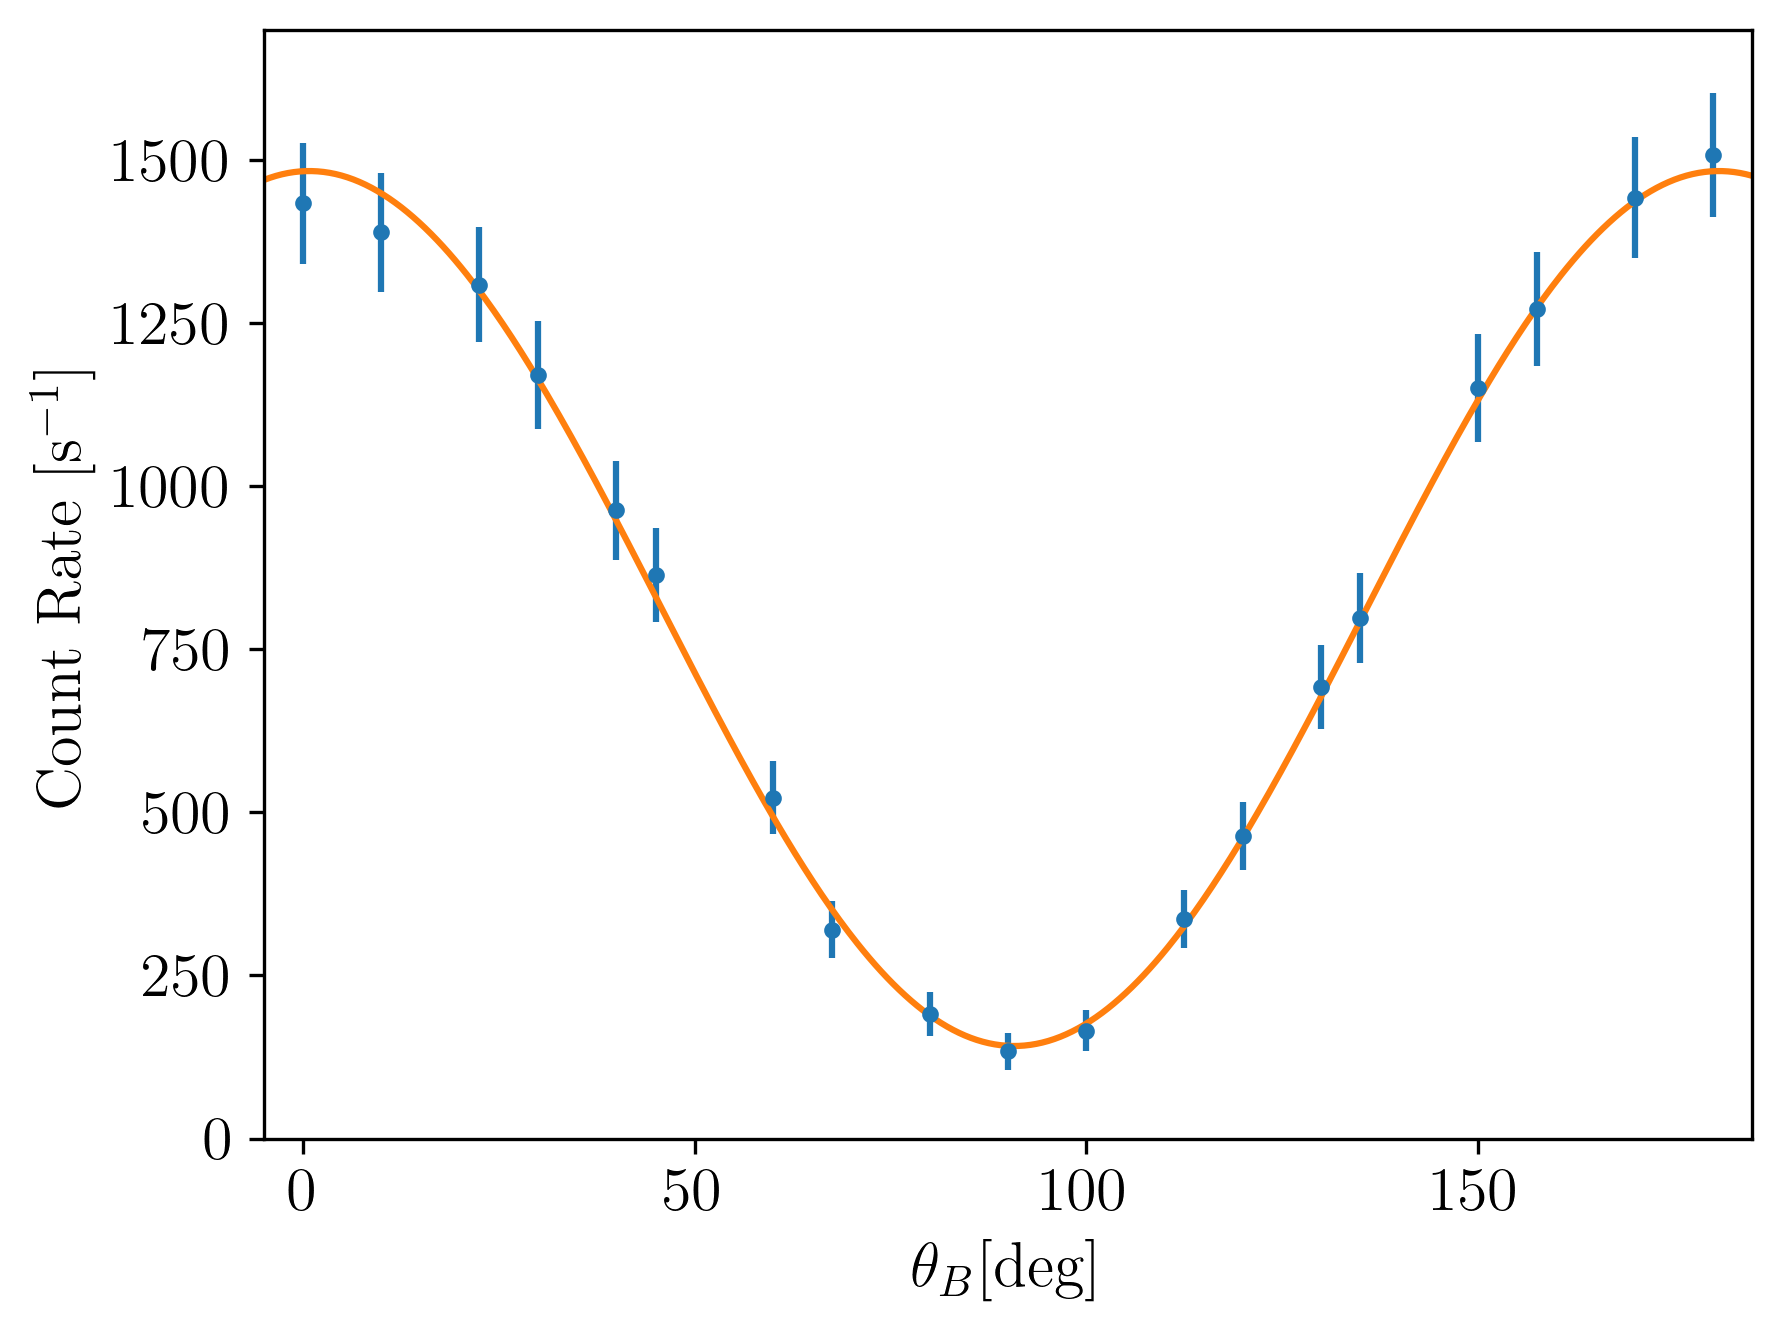

In [108]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit_adjusted_sigma.png")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))